**Nhóm 2:** Kịch bản 2

  + Nguyễn Trần Ngọc Ty - 23521758

  + Nguyễn Huỳnh Minh Phú - 23521183

  + Hà Xuân Hoàng - 23520516

In [ ]:
!pip install catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


# 1. Thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, f_oneway

import warnings
warnings.filterwarnings ('ignore')
# Hiển thị toàn bộ số dòng
pd.set_option("display.max_rows", None)
# Hiển thị toàn bộ số cột
pd.set_option("display.max_columns", None)
# Hiển thị toàn bộ nội dung trong từng ô (không cắt bớt)
pd.set_option("display.max_colwidth", None)


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
)
from sklearn.model_selection import (
    GridSearchCV, KFold, RandomizedSearchCV,
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 2. Đọc dữ liệu

Kết nối đường dẫn đến google drive chứa dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
df = pd.read_csv(
    '/content/drive/MyDrive/DS111_Data/ThuVienNhaDat_Final_Kichban2.csv'
)
print(df.shape)
df.head()

(20694, 21)


,title,original_post_date,ward/district,city/province,legal_doc,is_legal,area,total_bedroom,total_restroom,price_per_m2_million,price,month,day,quarter,is_weekend,area_log,price_log,location,bedroom_group,title_length,is_center
0,"Bán căn hộ TT AVIO, 82m2, nội thất cơ bản, thanh toán chỉ 9tr/tháng",2025-10-24,Dĩ An,Bình Dương,Sổ đỏ / Sổ hồng,1,82.0,3,2,37.80,3.10,10,24,4,0,4.418841,1.410987,Khác,vừa,vừa,0
1,"BÁN CHUNG CƯ CMT8, TRUNG TÂM QUẬN 10, 96 CĂN 53M LẦU2, SHR 2PN, CÓ BAN CÔNG GIÁ 2,65TỶ",2025-10-27,Quận 10,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,53.0,2,1,50.00,2.65,10,27,4,0,3.988984,1.294727,Hồ Chí Minh,nhỏ,dài,1
2,"Bán nhà Tân Hòa Đông, Bình Tân, diện tích 48m², sổ hồng đầy đủ, giá 4,45 tỷ",2025-10-25,Bình Tân,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,48.0,2,1,92.71,4.45,10,25,4,1,3.891820,1.695616,Hồ Chí Minh,nhỏ,vừa,0
3,"BÁN NHÀ HÀNG THƠM, CẦU TĂNG LONG, LÃ XUÂN OAI, XE TẢI THÔNG, CHỈ 5.9 TỶ",2025-10-25,Thủ Đức,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,99.0,2,1,59.60,5.90,10,25,4,1,4.605170,1.931521,Hồ Chí Minh,nhỏ,vừa,0
4,"Bán nhà phố Phan Anh, Bình Tân, 5 tầng, diện tích 64m², hẻm xe hơi, giá 7,1 tỷ",2025-10-24,Bình Tân,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,64.0,5,5,110.94,7.10,10,24,4,0,4.174387,2.091864,Hồ Chí Minh,vừa,vừa,0


# 3. Xử lý Outliers

In [34]:
# ---- 1. Tính IQR ----
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('=== Thống kê IQR cho biến "price" ===')
print(f"Q1 (25%): {Q1:.3f}")
print(f"Q3 (75%): {Q3:.3f}")
print(f"IQR     : {IQR:.3f}")
print(f"Lower bound: {lower_bound:.3f}")
print(f"Upper bound: {upper_bound:.3f}")
print()

# ---- 2. Xác định outlier ----
outliers = df[
    (df["price"] < lower_bound) | (df["price"] > upper_bound)
]

print(f"Số lượng outlier: {len(outliers)}")
print(f"Tỷ lệ outlier  : {len(outliers) / len(df) * 100:.2f}%")
print()

# ---- 3. In vài mẫu outlier ----
display_cols = ["price", "area", "ward/district", "city/province"]
display(outliers[display_cols].head(5))

print(f"Số dòng ban đầu : {len(df)}")

# ---- 4. Lọc dữ liệu ----
df = df[
    (df["price"] >= lower_bound) & (df["price"] <= upper_bound)
]

print(f"Số dòng sau lọc : {len(df)}")


=== Thống kê IQR cho biến "price" ===
Q1 (25%): 4.150
Q3 (75%): 12.500
IQR     : 8.350
Lower bound: -8.375
Upper bound: 25.025

Số lượng outlier: 1813
Tỷ lệ outlier  : 8.76%



,price,area,ward/district,city/province
9,27.60,88.0,Thanh Khê,Đà Nẵng
10,43.75,175.0,Long Biên,Hà Nội
37,55.00,282.0,Bình Thạnh,Hồ Chí Minh
41,26.50,160.0,Gò Vấp,Hồ Chí Minh
42,34.90,176.0,Bình Thạnh,Hồ Chí Minh


Số dòng ban đầu : 20694
Số dòng sau lọc : 18881


# 4. Mapping Encoding

In [35]:
# Mapping Encoding các giá trị "ngắn", "vừa",... thành các số nguyên 0, 1, 2
title_map = {
    "ngắn": 0,
    "vừa": 1,
    "dài": 2
}
bedroom_map = {
    "nhỏ": 0,
    "vừa": 1,
    "lớn": 2
}
df["title_length"] = df["title_length"].map(title_map)
df["bedroom_group"] = df["bedroom_group"].map(bedroom_map)
df.head()

,title,original_post_date,ward/district,city/province,legal_doc,is_legal,area,total_bedroom,total_restroom,price_per_m2_million,price,month,day,quarter,is_weekend,area_log,price_log,location,bedroom_group,title_length,is_center
0,"Bán căn hộ TT AVIO, 82m2, nội thất cơ bản, thanh toán chỉ 9tr/tháng",2025-10-24,Dĩ An,Bình Dương,Sổ đỏ / Sổ hồng,1,82.0,3,2,37.80,3.10,10,24,4,0,4.418841,1.410987,Khác,1,1,0
1,"BÁN CHUNG CƯ CMT8, TRUNG TÂM QUẬN 10, 96 CĂN 53M LẦU2, SHR 2PN, CÓ BAN CÔNG GIÁ 2,65TỶ",2025-10-27,Quận 10,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,53.0,2,1,50.00,2.65,10,27,4,0,3.988984,1.294727,Hồ Chí Minh,0,2,1
2,"Bán nhà Tân Hòa Đông, Bình Tân, diện tích 48m², sổ hồng đầy đủ, giá 4,45 tỷ",2025-10-25,Bình Tân,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,48.0,2,1,92.71,4.45,10,25,4,1,3.891820,1.695616,Hồ Chí Minh,0,1,0
3,"BÁN NHÀ HÀNG THƠM, CẦU TĂNG LONG, LÃ XUÂN OAI, XE TẢI THÔNG, CHỈ 5.9 TỶ",2025-10-25,Thủ Đức,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,99.0,2,1,59.60,5.90,10,25,4,1,4.605170,1.931521,Hồ Chí Minh,0,1,0
4,"Bán nhà phố Phan Anh, Bình Tân, 5 tầng, diện tích 64m², hẻm xe hơi, giá 7,1 tỷ",2025-10-24,Bình Tân,Hồ Chí Minh,Sổ đỏ / Sổ hồng,1,64.0,5,5,110.94,7.10,10,24,4,0,4.174387,2.091864,Hồ Chí Minh,1,1,0


# 5. Tách train/dev/test

In [36]:
X = df[
    [
        "is_legal", "area", "month", "ward/district","city/province",
        "title_length", "is_center",
        "total_bedroom", "total_restroom", "is_weekend", "day"
    ]
  ]
y = df["price_log"]

print(f"Kích thước X: {X.shape}")
print(X.head())
print()
print(f"Kích thước y: {y.shape}")
print(y.head())

Kích thước X: (18881, 11)
   is_legal  area  month ward/district city/province  title_length  is_center  \
0         1  82.0     10         Dĩ An    Bình Dương             1          0   
1         1  53.0     10       Quận 10   Hồ Chí Minh             2          1   
2         1  48.0     10      Bình Tân   Hồ Chí Minh             1          0   
3         1  99.0     10       Thủ Đức   Hồ Chí Minh             1          0   
4         1  64.0     10      Bình Tân   Hồ Chí Minh             1          0   

   total_bedroom  total_restroom  is_weekend  day  
0              3               2           0   24  
1              2               1           0   27  
2              2               1           1   25  
3              2               1           1   25  
4              5               5           0   24  

Kích thước y: (18881,)
0    1.410987
1    1.294727
2    1.695616
3    1.931521
4    2.091864
Name: price_log, dtype: float64


In [37]:
# Train + Temp
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print()
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_test: {y_test.shape}")

Kích thước X_train: (15104, 11)
Kích thước y_train: (15104,)

Kích thước X_test: (3777, 11)
Kích thước y_test: (3777,)


# 6. Xây dựng Pipeline tiền xử lý dữ liệu và huấn luyện mô hình

In [38]:
# Danh sách các biến chuẩn hoá Standardization
standard_features = [
    "month",
    "day",
    "area",
    "total_bedroom",
    "total_restroom"
]

# Danh sách các biến thực hiện One-hot Encoding
onehot_features = [
    # "location",
    # "title_length"
    "ward/district", "city/province",
    # "legal_doc",
]

# Danh sách các biến không thực hiện tiền xử lý
passthrough_features = [
    "is_legal",
    "is_weekend",
    "is_center",
    "title_length",   # ordinal encoded
    # "bedroom_group", # ordinal encoded
]

# Tổng hợp
preprocessor = ColumnTransformer([
    ("standard", StandardScaler(), standard_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), onehot_features),
    ("pass", "passthrough", passthrough_features)
])

In [39]:
# Mô hình Linear Regression
model_lr = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

# Mô hình Random Forest
model_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42
    ))
])

# Mô hình Support Vector Regressor
model_svr = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", SVR(
            kernel="rbf",
            C=100,
            epsilon=0.1,
            gamma="scale"
        ))
    ]
)

# Mô hình XGBoost
model_xgb = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

# Mô hình LightGBM
model_lgbm = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ]
)

# Mô hình CatBoost
model_cat = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=8,
            loss_function="RMSE",
            random_seed=42,
            verbose=0
        ))
    ]
)

In [40]:
def evaluate_and_plot_models(models, X_train, y_train, X_test, y_test):
    """
    Huấn luyện, đánh giá và trực quan hóa hiệu năng của nhiều mô hình hồi quy.

    Hàm này nhận vào một tập các mô hình (scikit-learn estimators),
    tiến hành:
      1. Fit từng mô hình trên tập huấn luyện
      2. Dự đoán trên cả train và test
      3. Tính các chỉ số đánh giá phổ biến:
         - R² (độ phù hợp mô hình)
         - RMSE (sai số căn bậc hai trung bình)
         - MAE (sai số tuyệt đối trung bình)
      4. Vẽ các biểu đồ so sánh hiệu năng giữa các mô hình:
         - Biểu đồ cột R²: Train vs Test
         - Biểu đồ cột RMSE trên tập Test
         - Biểu đồ cột MAE trên tập Test

    Parameters
    ----------
    models : dict
        Dictionary chứa các mô hình cần đánh giá,
        có dạng {model_name: model_object}.
        Ví dụ:
        {
            "Linear": LinearRegression(),
            "Ridge": Ridge(alpha=1.0),
            "RandomForest": RandomForestRegressor()
        }

    X_train : array-like or DataFrame
        Tập đặc trưng huấn luyện.

    y_train : array-like or Series
        Nhãn (target) của tập huấn luyện.

    X_test : array-like or DataFrame
        Tập đặc trưng kiểm tra.

    y_test : array-like or Series
        Nhãn (target) của tập kiểm tra.

    Returns
    -------
    df_results : pandas.DataFrame
        Bảng tổng hợp kết quả đánh giá cho từng mô hình,
        mỗi hàng tương ứng với một mô hình, bao gồm:
        - train_R2, test_R2
        - train_RMSE, test_RMSE
        - train_MAE, test_MAE

    Notes
    -----
    - Hàm giả định rằng các mô hình trong `models` đã được cấu hình sẵn
      (ví dụ: pipeline preprocessing + model nếu cần).
    - Phù hợp để so sánh hiện tượng overfitting/underfitting
      thông qua chênh lệch Train vs Test.
    - Dùng tốt trong giai đoạn EDA, baseline modeling và model selection.
    """

    results = {}

    # ===== Evaluate =====
    for name, model in models.items():
        model.fit(X_train, y_train)

        y_tr_pred = model.predict(X_train)
        y_te_pred = model.predict(X_test)

        results[name] = {
            "train_R2": r2_score(y_train, y_tr_pred),
            "test_R2": r2_score(y_test, y_te_pred),
            "train_RMSE": np.sqrt(mean_squared_error(y_train, y_tr_pred)),
            "test_RMSE": np.sqrt(mean_squared_error(y_test, y_te_pred)),
            "train_MAE": mean_absolute_error(y_train, y_tr_pred),
            "test_MAE": mean_absolute_error(y_test, y_te_pred),
        }

    df_results = pd.DataFrame(results).T

    # ===== Plot R2 =====
    x = np.arange(len(df_results.index))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, df_results["train_R2"], width, label="Train R2")
    plt.bar(x + width/2, df_results["test_R2"], width, label="Test R2")
    plt.xticks(x, df_results.index, rotation=30)
    plt.ylabel("R²")
    plt.title("R² Score: Train vs Test")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ===== Plot RMSE (Test) =====
    plt.figure()
    plt.bar(df_results.index, df_results["test_RMSE"])
    plt.xticks(rotation=30)
    plt.ylabel("RMSE")
    plt.title("Test RMSE Comparison")
    plt.tight_layout()
    plt.show()

    # ===== Plot MAE (Test) =====
    plt.figure()
    plt.bar(df_results.index, df_results["test_MAE"])
    plt.xticks(rotation=30)
    plt.ylabel("MAE")
    plt.title("Test MAE Comparison")
    plt.tight_layout()
    plt.show()

    return df_results


# 7. Huấn luyện mô hình và đánh giá kết quả

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 539
[LightGBM] [Info] Number of data points in the train set: 15104, number of used features: 92
[LightGBM] [Info] Start training from score 1.989817


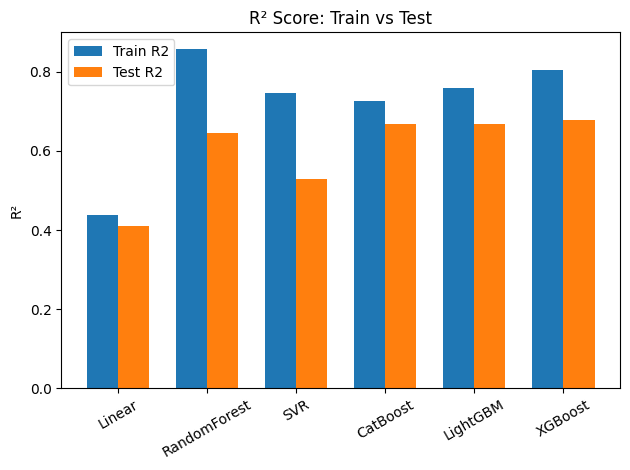

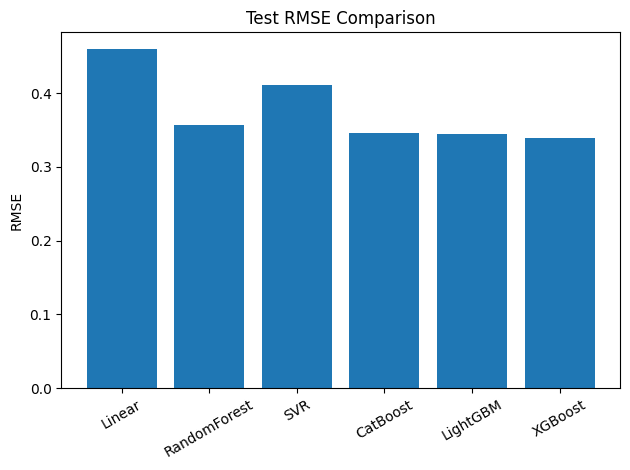

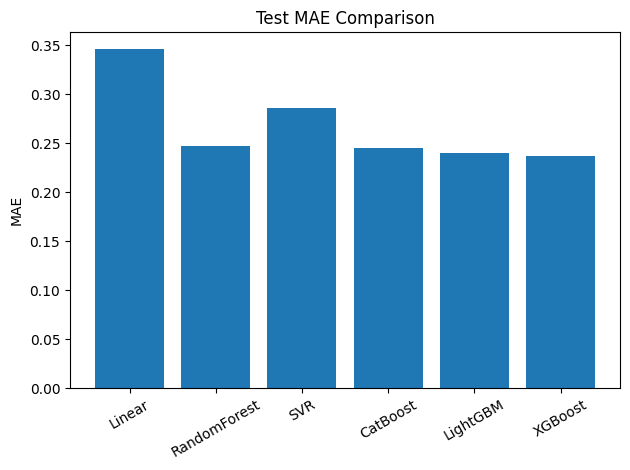

,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
Linear,0.437544,0.411185,0.459105,0.459330,0.342760,0.345706
RandomForest,0.857472,0.646336,0.231110,0.355984,0.165182,0.246616
SVR,0.747052,0.528755,0.307881,0.410921,0.200938,0.285448
CatBoost,0.726653,0.667469,0.320055,0.345185,0.229492,0.244776
LightGBM,0.759999,0.669444,0.299898,0.344158,0.210908,0.240284
XGBoost,0.804702,0.679395,0.270531,0.338938,0.192129,0.236460


In [41]:
models = {
    "Linear": model_lr,
    "RandomForest": model_rf,
    "SVR": model_svr,
    "CatBoost": model_cat,
    "LightGBM": model_lgbm,
    "XGBoost": model_xgb
}

df_results = evaluate_and_plot_models(
    models,
    X_train, y_train,
    X_test, y_test
)

df_results

## a. Trọng số **Linear Regression**

In [42]:
feature_names = model_lr.named_steps["preprocess"].get_feature_names_out()

print("Số feature sau preprocess:",
      model_lr.named_steps["preprocess"].transform(X_train[:1]).shape[1])

print("Số coef:",
      model_lr.named_steps["model"].coef_.shape[0])

Số feature sau preprocess: 243
Số coef: 243


In [43]:
lr_model = model_lr.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_model.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

print("=== Linear Regression Coefficients ===")
display(coef_df.head(15))

=== Linear Regression Coefficients ===


,feature,coefficient
50,cat__ward/district_Dương Minh Châu,1.122125
25,cat__ward/district_Bến Tre,-1.121724
171,cat__ward/district_Vĩnh Cửu,-1.117282
158,cat__ward/district_Tân Phú Đông,1.015185
150,cat__ward/district_Trảng Bom,-1.011796
130,cat__ward/district_Sơn Tây,0.976357
47,cat__ward/district_Duy Xuyên,0.896099
8,cat__ward/district_Biên Hòa,-0.878143
60,cat__ward/district_Hà Trung,-0.855910
209,cat__city/province_Hậu Giang,-0.833890


## b. Feature Importance **Random Forest**

In [44]:
rf_model = model_rf.named_steps["model"]

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("=== Random Forest Feature Importance ===")
display(rf_importance.head(15))

=== Random Forest Feature Importance ===


,feature,importance
3,standard__total_bedroom,0.342373
2,standard__area,0.192685
4,standard__total_restroom,0.064673
1,standard__day,0.046248
241,pass__is_center,0.042068
205,cat__city/province_Hà Nội,0.035109
0,standard__month,0.032659
193,cat__city/province_Bình Dương,0.024675
210,cat__city/province_Hồ Chí Minh,0.023738
238,cat__city/province_Đồng Nai,0.016636


## c. Feature Importance **XGBoost**

In [45]:
xgb_model = model_xgb.named_steps["model"]

xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("=== XGBoost Feature Importance ===")
display(xgb_importance.head(15))

=== XGBoost Feature Importance ===


,feature,importance
193,cat__city/province_Bình Dương,0.050413
238,cat__city/province_Đồng Nai,0.044602
241,pass__is_center,0.042312
210,cat__city/province_Hồ Chí Minh,0.035975
235,cat__city/province_Đà Nẵng,0.034064
205,cat__city/province_Hà Nội,0.032875
213,cat__city/province_Long An,0.028260
12,cat__ward/district_Bình Chánh,0.026113
206,cat__city/province_Hưng Yên,0.023455
147,cat__ward/district_Thủ Đức,0.023417


## d. Feature Importance **LightGBM**

In [46]:
lgbm_model = model_lgbm.named_steps["model"]

lgbm_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("=== LightGBM Feature Importance ===")
display(lgbm_importance.head(15))

=== LightGBM Feature Importance ===


,feature,importance
2,standard__area,4147
1,standard__day,2421
4,standard__total_restroom,1297
3,standard__total_bedroom,1149
0,standard__month,1071
242,pass__title_length,350
205,cat__city/province_Hà Nội,279
210,cat__city/province_Hồ Chí Minh,278
241,pass__is_center,226
240,pass__is_weekend,155


## e. Feature Importance **CatBoost**

In [47]:
cat_model = model_cat.named_steps["model"]

cat_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

print("=== CatBoost Feature Importance ===")
display(cat_importance.head(15))

=== CatBoost Feature Importance ===


,feature,importance
2,standard__area,21.788377
4,standard__total_restroom,16.062801
205,cat__city/province_Hà Nội,10.394891
3,standard__total_bedroom,10.321936
241,pass__is_center,5.860624
210,cat__city/province_Hồ Chí Minh,5.653137
0,standard__month,4.549565
193,cat__city/province_Bình Dương,2.964954
1,standard__day,2.686763
12,cat__ward/district_Bình Chánh,2.272191


## f. Tổng hợp

In [48]:
summary = pd.DataFrame({
    "Linear_coef": coef_df.set_index("feature")["coefficient"],
    "RF_importance": rf_importance.set_index("feature")["importance"],
    "XGB_importance": xgb_importance.set_index("feature")["importance"],
    "LGBM_importance": lgbm_importance.set_index("feature")["importance"],
    "Cat_importance": cat_importance.set_index("feature")["importance"],
}).fillna(0)

display(summary.head(15))


,Linear_coef,RF_importance,XGB_importance,LGBM_importance,Cat_importance
feature,,,,,
cat__city/province_An Giang,0.206468,0.000001,0.000000,0,0.000000
cat__city/province_Bà Rịa - Vũng Tàu,0.228794,0.000445,0.005708,4,0.002038
cat__city/province_Bình Dương,-0.241437,0.024675,0.050413,86,2.964954
cat__city/province_Bình Thuận,-0.260442,0.000237,0.005248,0,0.071952
cat__city/province_Bình Định,-0.185908,0.000112,0.002499,0,0.004995
cat__city/province_Bắc Giang,-0.248377,0.000002,0.000000,0,0.000000
cat__city/province_Bắc Ninh,-0.004780,0.000297,0.002168,1,0.003190
cat__city/province_Bến Tre,0.803196,0.000112,0.001993,0,0.000000
cat__city/province_Cao Bằng,-0.285287,0.000000,0.000000,0,0.000000
